In [44]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [45]:
X , y = make_classification(n_features = 5 , n_redundant = 0 , n_informative = 5 , n_clusters_per_class = 1 )

In [46]:
df = pd.DataFrame(X , columns = ['col1' , 'col2' , 'col3' , 'col4' , 'col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.529918,1.272537,-1.669654,-0.889785,-0.142119,1
1,0.747627,1.509587,2.009533,-1.906291,2.627683,0
2,0.162717,1.720126,-2.358373,-1.027220,-2.225198,1
3,-1.669292,1.604549,-0.247145,-2.084655,0.055742,1
4,-1.782918,-0.033693,-0.939817,-0.233563,-0.821031,1


In [47]:
#function for row sampling
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]) , replace = True)


In [48]:
#function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[: -1] , int(percent*df.shape[1]))
  return df[cols]


In [49]:
#function for combined sampling
def combined_sampling(df , row_percent , col_percent):
  new_df = sample_rows(df , row_percent)
  return sample_features(new_df , col_percent)

In [50]:
df1 = sample_rows(df , 0.2)

In [51]:
df2 = sample_rows(df, 0.2)

In [52]:
df3 = sample_rows(df, 0.2)

In [53]:
df1.shape

(20, 6)

In [54]:
df2.shape

(20, 6)

In [55]:
df.shape

(100, 6)

In [56]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [57]:
clf1.fit(df1.iloc[: , 0:5] , df1.iloc[: , -1])
clf2.fit(df2.iloc[: , 0:5] , df2.iloc[: , -1])
clf3.fit(df3.iloc[: , 0:5] , df3.iloc[: , -1])

DecisionTreeClassifier()

In [58]:
from sklearn.tree import plot_tree

[Text(0.5, 0.8333333333333334, 'x[3] <= -0.351\ngini = 0.42\nsamples = 20\nvalue = [14, 6]'),
 Text(0.25, 0.5, 'x[4] <= 1.737\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.75, 0.5, 'x[1] <= -0.245\ngini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]')]

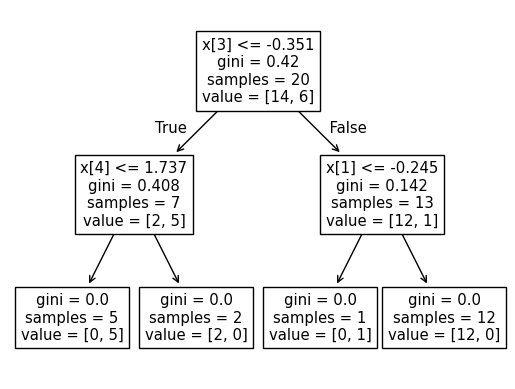

In [59]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[2] <= -0.076\ngini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.625, 0.5, '  False')]

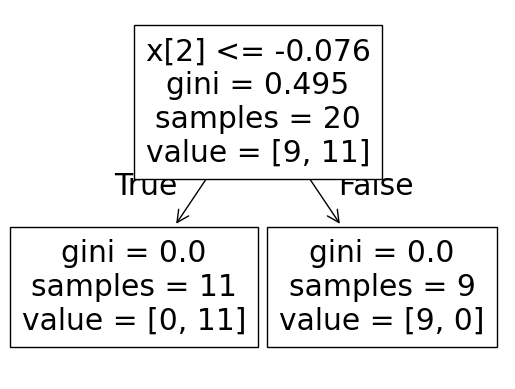

In [60]:
plot_tree(clf2)

[Text(0.4, 0.8333333333333334, 'x[0] <= -1.004\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= -1.323\ngini = 0.355\nsamples = 13\nvalue = [10, 3]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]')]

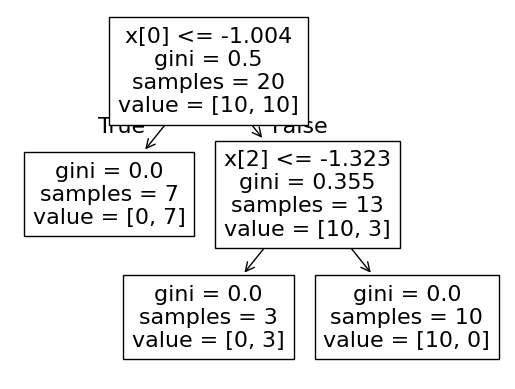

In [61]:
plot_tree(clf3)

In [62]:
clf1.predict(np.array([-1.139440 , 	0.899917 ,	1.138081 , 	0.765367 , 	-0.861283]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [64]:
clf2.predict(np.array([0.747627	 , 1.509587	, 2.009533 , 	-1.906291 ,	2.627683]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])